# Parameter Information
1. So    :   initial value, that will be the last value of the historical data
2. dt    :   time increment, 1 month in our case. It is determined by the frequency of the historical data.For example, if the historical data is daily, dt should be 1/30 (1 month = 30 days). But it should be consistent with T.
3. T     :   length of the prediction time horizon, how many time points to predict. It should be consistent with dt. For example, if dt is 1 month and we want to predict for 6 months, T should be 6.
4. N     :   number of time points in the prediction time horizon, it is calculated by T/dt. For example, if T is 6 months and dt is 1 month, N should be 6. It is the number of time points within our prediction time horizon which should be consistent with our historical data in terms of time increment magnitude.
5. t     :   array for time points in the prediction time horizon [1, 2, 3, .. , N]. This is an array where we show the time progression in our model. It is like a time ticker where we measure time by counting the number of time points elapsed.
6. mu    :  Mean change in daily crime counts over the selected historical period. It is the average change in the historical data. It is calculated by taking the difference between each consecutive data point, summing them up and dividing by the number of data points. We will then use mu in our drift component calculation. It will have an effect on the long-term movement of the daliy number of crimes
7. sigma :   standard deviation of historical data (number of crimes per day). sigma will contribute by scaling the magnitude of random shock so that the small fluctuations occur in accordance with the historical volatility of the data.
8. b     :   array for brownian increments. Here array b, for each corresponding prediction time point, stores a random number coming from the standard normal distribution. These random numbers will add the random shocks. b is the random shock being applied to the data at a time point when predicting the data of the NEXT time point. So, suppose, at time point 3, the daily number of crimes is S_3. When predicting time point 4, b(4) is applied to S_3 as the random shock.
9. W     :   array for brownian path and it determines how the daily number of crimes fluctuate from beginning time point (So) to some other time point t. It means that it includes the effects of all the random shocks since the beginning of the prediction time horizon. It is the total effect of randomness incorporated into So(initial stock price) until the specific time point we are concerned with. So, suppose, we are predicting time point 4, we need to apply all the random shocks up-to and including time point 4 to So. Therefore, instead of b(4), we use W(4) which is the cumulative sum of array b elements with index less than or equal to 4.

Source : https://medium.com/data-science/simulating-stock-prices-in-python-using-geometric-brownian-motion-8dfd6e8c6b18


## Import Data and Libraries

In [ ]:
from random import seed

import folium
from folium.plugins import MarkerCluster
import calendar
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import learning_curve
import numpy as np
from sklearn.model_selection import train_test_split, KFold,GridSearchCV, StratifiedKFold, RandomizedSearchCV
from sklearn.metrics import mean_squared_error
import os
import pandas as pd
import geopandas as gpd
import plotly.express as px

In [ ]:
# Fájl elérési útja
csv_path = 'data/Number_of_crimes_per_day.csv'

# Beolvasás
df = pd.read_csv(csv_path)

In [279]:
plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.facecolor"] = "white"
plt.rcParams["savefig.facecolor"] = "white"
plt.rcParams["savefig.edgecolor"] = "white"
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.facecolor": "white",
    "savefig.edgecolor": "white",

    "text.color": "black",
    "axes.labelcolor": "black",
    "axes.titlecolor": "black",
    "xtick.color": "black",
    "ytick.color": "black",

    "legend.facecolor": "white",
    "legend.edgecolor": "black",
    "legend.labelcolor": "black",
})

## Geometric Brownian Motion Model Implementation - Define Parameters

In [265]:
# Time increment, 1 month in our case
dt = 1 # 1 month
# Length of the prediction time horizon, how many time points to predict
T = 8  # 8 monthss
# Number of time points in the prediction time horizon
N = int(T / dt)  # 9 time points
# Array for time points in the prediction time horizon [1, 2, 3, .. , N]
t = np.arange(1, int(N) + 1)
print(t)
scen_size = 3# number of scenarios to simulate
rng = np.random.default_rng(seed=42) # random number generator with a fixed seed for reproducibility

[1 2 3 4 5 6 7 8]


In [266]:
districts = sorted(df['District'].dropna().astype(int).unique())
district_info = {}
log_returns_dict = {}

for d in districts:
    ddf = df[df['District'] == d].copy()
    ddf["Month"] = ddf["Month"].astype(int)
    ddf = ddf.drop(columns=['count', 'Number_of_days_in_month', 'District'])
    hist = ddf[ddf['Year'].between(2001, 2024)]
    pred_df = ddf[ddf['Year'] == 2025].drop(columns=['Number of Crimes Per Day'])
    pred_df['Month'] = pred_df['Month'].astype(int)
    pred_df = pred_df[pred_df['Month'].between(1, 8)].reset_index(drop=True)
    valid = ddf[
        (ddf['Year'] == 2025) &
        (ddf['Month'].between(1, 8))
    ]['Number of Crimes Per Day'].reset_index(drop=True)

    if hist.empty or pred_df.empty or len(pred_df) != 8:
        continue

    S0_d = hist['Number of Crimes Per Day'].values[-1]
    log_hozamok_d = np.log(hist["Number of Crimes Per Day"]/hist["Number of Crimes Per Day"].shift(1)).dropna()

    return_index = pd.MultiIndex.from_arrays(
        [
            hist['Year'].iloc[1:].astype(int).to_numpy(),
            hist['Month'].iloc[1:].astype(int).to_numpy()
        ],
        names=['Year', 'Month']
    )

    log_returns_dict[d] = pd.Series(log_hozamok_d.to_numpy(), index=return_index)
    u_atlag_d = log_hozamok_d.mean()
    u_szoras_d = log_hozamok_d.std(ddof=1)
    mu_d = float(u_atlag_d + 0.5 * (u_szoras_d ** 2)) if log_hozamok_d.size else 0.0
    sigma_d = float(u_szoras_d) if log_hozamok_d.size else 0.0
    district_info[d] = {
        "S0": S0_d,
        "mu": mu_d,
        "sigma": sigma_d,
        "future_cal": pred_df[['Year', 'Month']].copy()}

# Korrelációs mátrix a log hozamokra

In [267]:
# Azok a körzetek maradnak, amelyekhez minden szükséges adat rendelkezésre állt
districts_model = sorted(district_info.keys())

# Loghozamok közös DataFrame-ben
log_returns_df = pd.DataFrame({
    d: log_returns_dict[d]
    for d in districts_model
}).sort_index()

# Korrelációs mátrix
corr_matrix = log_returns_df.corr()
corr_matrix = corr_matrix.loc[districts_model, districts_model]

corr_matrix.round(2)


,1,2,3,4,5,6,7,8,9,10,...,14,15,16,17,18,19,20,22,24,25
1,1.00,0.39,0.36,0.39,0.39,0.40,0.44,0.39,0.35,0.35,...,0.39,0.31,0.40,0.23,0.63,0.41,0.13,0.39,0.29,0.41
2,0.39,1.00,0.60,0.62,0.56,0.64,0.62,0.60,0.64,0.60,...,0.58,0.50,0.42,0.41,0.49,0.59,0.36,0.60,0.51,0.58
3,0.36,0.60,1.00,0.59,0.70,0.66,0.68,0.62,0.61,0.62,...,0.56,0.56,0.52,0.42,0.50,0.58,0.38,0.57,0.51,0.53
4,0.39,0.62,0.59,1.00,0.64,0.65,0.65,0.58,0.64,0.57,...,0.52,0.58,0.48,0.36,0.54,0.57,0.31,0.55,0.50,0.56
5,0.39,0.56,0.70,0.64,1.00,0.69,0.69,0.60,0.60,0.64,...,0.56,0.58,0.51,0.41,0.48,0.50,0.35,0.59,0.50,0.58
6,0.40,0.64,0.66,0.65,0.69,1.00,0.69,0.66,0.56,0.63,...,0.59,0.59,0.47,0.41,0.55,0.54,0.32,0.58,0.52,0.59
7,0.44,0.62,0.68,0.65,0.69,0.69,1.00,0.63,0.62,0.62,...,0.54,0.55,0.49,0.36,0.51,0.55,0.39,0.63,0.51,0.60
8,0.39,0.60,0.62,0.58,0.60,0.66,0.63,1.00,0.62,0.58,...,0.54,0.51,0.51,0.47,0.48,0.56,0.41,0.62,0.62,0.61
9,0.35,0.64,0.61,0.64,0.60,0.56,0.62,0.62,1.00,0.63,...,0.51,0.50,0.47,0.45,0.45,0.64,0.38,0.56,0.57,0.56
10,0.35,0.60,0.62,0.57,0.64,0.63,0.62,0.58,0.63,1.00,...,0.55,0.50,0.46,0.41,0.46,0.60,0.38,0.62,0.52,0.51


# Cholesky dekompozíció a korrelációs mátrixra

In [269]:
corr_values = corr_matrix.to_numpy()

try:
    L = np.linalg.cholesky(corr_values)

except np.linalg.LinAlgError:
    print("A korrelációs mátrix nem szigorúan pozitív definit. Javítás történik.")

    # Sajátértékes korrekció numerikus stabilitás érdekében
    eigvals, eigvecs = np.linalg.eigh(corr_values)
    eigvals = np.clip(eigvals, 1e-10, None)

    corr_values = eigvecs @ np.diag(eigvals) @ eigvecs.T

    # Újranormálás, hogy a főátló ismét 1 legyen
    d = np.sqrt(np.diag(corr_values))
    corr_values = corr_values / np.outer(d, d)

    np.fill_diagonal(corr_values, 1.0)

    L = np.linalg.cholesky(corr_values)

    # A javított mátrixot visszaírjuk DataFrame-be
    corr_matrix = pd.DataFrame(
        corr_values
    )

In [270]:
n_districts = len(districts_model)

# Független standard normális zajok:
# shape = (szcenáriók száma, hónapok száma, körzetek száma)
Z = rng.normal(
    loc=0,
    scale=1,
    size=(scen_size, N, n_districts)
)

# Korrelált Brown-inkrementumok
# Minden időpontban és minden szcenárióban a körzetek zajait összekapcsoljuk
dB = (Z @ L.T) * np.sqrt(dt)

# Brown-pályák: kumulatív összeg időben
B = np.cumsum(dB, axis=1)

print("Z alakja:", Z.shape)
print("dB alakja:", dB.shape)
print("B alakja:", B.shape)

Z alakja: (3, 8, 22)
dB alakja: (3, 8, 22)
B alakja: (3, 8, 22)


In [271]:
# Paramétervektorok körzetenként
S0_arr = np.array([district_info[d]["S0"] for d in districts_model])
mu_arr = np.array([district_info[d]["mu"] for d in districts_model])
sigma_arr = np.array([district_info[d]["sigma"] for d in districts_model])

# Drift tag:
# shape = (1, hónapok, körzetek)
drift = (
    (mu_arr - 0.5 * sigma_arr ** 2)[None, None, :]
    * t[None, :, None]
)

# Diffúziós tag:
# shape = (szcenáriók, hónapok, körzetek)
diffusion = sigma_arr[None, None, :] * B

# GBM előrejelzések
# shape = (szcenáriók, hónapok, körzetek)
S = S0_arr[None, None, :] * np.exp(drift + diffusion)

print("S alakja:", S.shape)

S alakja: (3, 8, 22)


In [272]:
prediction_rows = []

for d_idx, d in enumerate(districts_model):
    future_calendar = district_info[d]["future_cal"].copy()

    for s_idx in range(scen_size):
        temp = future_calendar.copy()

        temp["District"] = d
        temp["Scenario"] = f"Scenario {s_idx + 1}"
        temp["Predicted Crimes"] = S[s_idx, :, d_idx]

        prediction_rows.append(temp)

predictions_long = pd.concat(prediction_rows, ignore_index=True)

predictions_long = predictions_long[
    ["District", "Year", "Month", "Scenario", "Predicted Crimes"]
]

predictions_long.head()

,District,Year,Month,Scenario,Predicted Crimes
0,1,2025,1,Scenario 1,36.974277
1,1,2025,2,Scenario 1,42.277476
2,1,2025,3,Scenario 1,42.800561
3,1,2025,4,Scenario 1,41.166071
4,1,2025,5,Scenario 1,43.379537


In [273]:
predictions_by_district = (
    predictions_long
    .pivot_table(
        index=["District", "Year", "Month"],
        columns="Scenario",
        values="Predicted Crimes"
    )
    .reset_index()
)

predictions_by_district.columns.name = None

predictions_by_district.head()

,District,Year,Month,Scenario 1,Scenario 2,Scenario 3
0,1,2025,1,36.974277,42.542716,33.576540
1,1,2025,2,42.277476,42.495429,35.668851
2,1,2025,3,42.800561,41.438288,38.760697
3,1,2025,4,41.166071,34.129495,38.445728
4,1,2025,5,43.379537,35.928173,37.632453


In [ ]:
elso_korzet=(predictions_by_district[predictions_by_district['District'] == 1].round(2).drop(['Year', 'District'], axis=1))
#elso_korzet.to_csv(
    #"docs/Szakdolgozat docs/Results/gbm_pred_1korzet_2.csv",
    #index=False
#)

In [274]:
actual_values = df[
    (df["Year"] == 2025) &
    (df["Month"].astype(int).between(1, 8))
][["District", "Year", "Month", "Number of Crimes Per Day"]].copy()

actual_values["District"] = actual_values["District"].astype(int)
actual_values["Month"] = actual_values["Month"].astype(int)

actual_values = actual_values.rename(
    columns={"Number of Crimes Per Day": "Actual Crimes"}
)

evaluation_df = predictions_long.merge(
    actual_values,
    on=["District", "Year", "Month"],
    how="left"
)

evaluation_df["Error"] = (
    evaluation_df["Actual Crimes"] -
    evaluation_df["Predicted Crimes"]
)

evaluation_df["SquaredError"] = evaluation_df["Error"] ** 2

rmse_by_district = (
    evaluation_df
    .groupby(["District", "Scenario"])["SquaredError"]
    .mean()
    .pow(0.5)
    .unstack("Scenario")
    .reset_index()
)

# Oszlopok sorrendje
scenario_columns = [f"Scenario {s}" for s in range(1, scen_size + 1)]
rmse_by_district = rmse_by_district[["District"] + scenario_columns]

rmse_by_district

Scenario,District,Scenario 1,Scenario 2,Scenario 3
0,1,6.131895,5.623081,5.091682
1,2,3.827945,5.303842,11.585256
2,3,3.949990,5.945537,8.409115
3,4,3.828765,3.822918,4.320623
4,5,3.409101,3.396200,3.876211
5,6,6.683899,5.230162,4.736018
6,7,3.424860,8.009061,3.900868
7,8,1.786295,6.418980,5.614248
8,9,3.084627,3.352719,4.293194
9,10,3.975340,5.921476,3.696366


In [275]:
global_rmse_by_scenario = (
    evaluation_df
    .groupby("Scenario")["SquaredError"]
    .mean()
    .pow(0.5)
    .sort_values()
)

best_global_scenario = global_rmse_by_scenario.index[0]

print("Globálisan legjobb szcenárió:", best_global_scenario)
print("Globális RMSE:", global_rmse_by_scenario.iloc[0])

Globálisan legjobb szcenárió: Scenario 1
Globális RMSE: 4.450579610767228


In [276]:
best_predictions = (
    evaluation_df[
        evaluation_df["Scenario"] == best_global_scenario
    ]
    [
        [
            "District",
            "Year",
            "Month",
            "Scenario",
            "Predicted Crimes",
            "Actual Crimes",
            "Error"
        ]
    ]
    .sort_values(["District", "Year", "Month"])
    .reset_index(drop=True)
)

best_predictions

,District,Year,Month,Scenario,Predicted Crimes,Actual Crimes,Error
0,1,2025,1,Scenario 1,36.974277,32.451613,-4.522664
1,1,2025,2,Scenario 1,42.277476,33.750000,-8.527476
2,1,2025,3,Scenario 1,42.800561,37.129032,-5.671528
3,1,2025,4,Scenario 1,41.166071,36.533333,-4.632737
4,1,2025,5,Scenario 1,43.379537,37.483871,-5.895666
...,...,...,...,...,...,...,...
171,25,2025,4,Scenario 1,33.877318,33.066667,-0.810651
172,25,2025,5,Scenario 1,31.424207,31.000000,-0.424207
173,25,2025,6,Scenario 1,30.207054,31.633333,1.426279
174,25,2025,7,Scenario 1,30.045984,33.806452,3.760468


In [277]:
overall_mae = np.mean(np.abs(best_predictions["Error"]))
overall_rmse = np.sqrt(np.mean(best_predictions["Error"] ** 2))

nonzero_mask = best_predictions["Actual Crimes"] != 0
overall_mape = (
    np.mean(
        np.abs(
            best_predictions.loc[nonzero_mask, "Error"] /
            best_predictions.loc[nonzero_mask, "Actual Crimes"]
        )
    )
    * 100
)

overall_accuracy = 100 - overall_mape

overall_metrics = {
    "RMSE": overall_rmse,
    "MAE": overall_mae,
    "MAPE": overall_mape,
    "Accuracy": overall_accuracy,
}

overall_metrics = pd.DataFrame([overall_metrics]).round(2)

overall_metrics

,RMSE,MAE,MAPE,Accuracy
0,4.45,3.48,11.96,88.04


In [ ]:
overall_metrics.to_csv(
    "docs/Szakdolgozat docs/Results/gbm_overall_metrics.csv",
    index=False
)

## Analysis and Visualization of Prediction Results

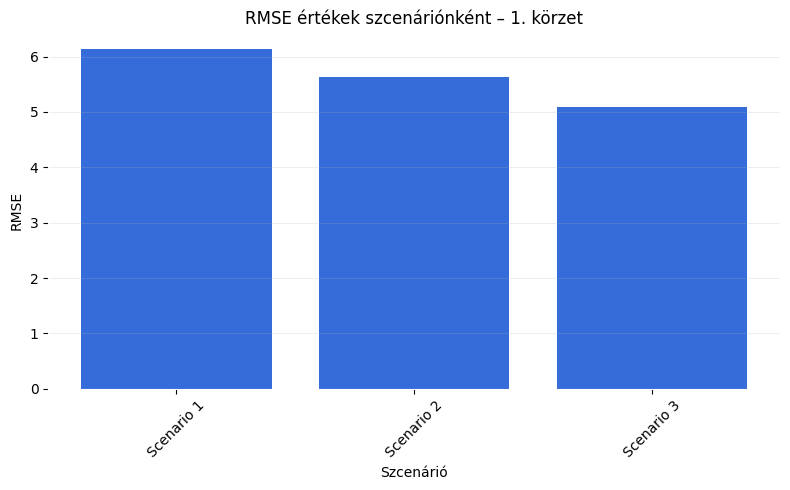

In [280]:
# Visualize the RMSE values for each scenario
import matplotlib.pyplot as plt

# Melyik körzet RMSE értékeit szeretnéd kirajzolni?
district_to_plot = 1

# Az adott körzet RMSE értékeinek kiválasztása
rmse_plot_data = (
    rmse_by_district[
        rmse_by_district["District"] == district_to_plot
    ]
    .drop(columns="District")
    .T
    .reset_index()
)

rmse_plot_data.columns = ["Scenario", "RMSE"]

# Ábra készítése
plt.figure(figsize=(8, 5))

plt.bar(
    rmse_plot_data["Scenario"],
    rmse_plot_data["RMSE"]
)

plt.title(f"RMSE értékek szcenáriónként – {district_to_plot}. körzet")
plt.xlabel("Szcenárió")
plt.ylabel("RMSE")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("docs/Szakdolgozat docs/Images/Results_img/rmse_by_scenario_district_1.png")

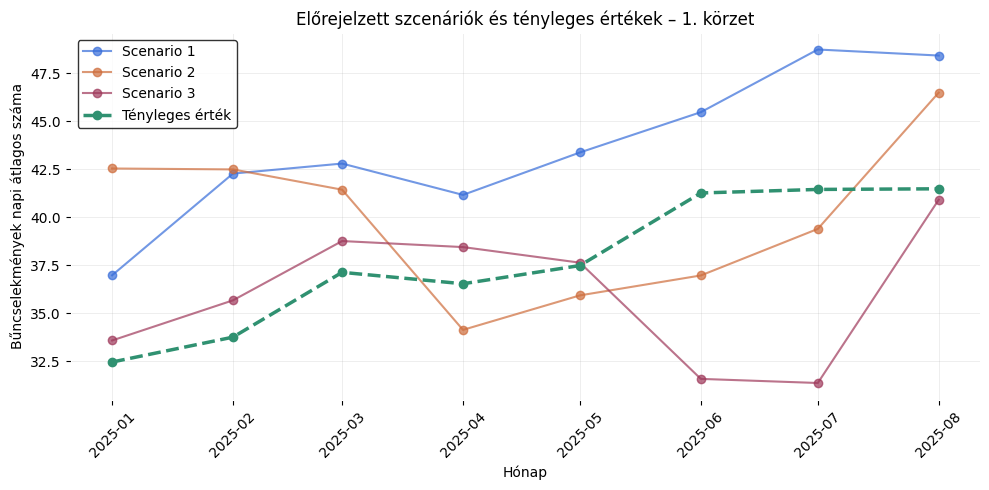

In [283]:
# Melyik körzetet szeretnéd kirajzolni?
district_to_plot = 1

# Előrejelzések kiválasztása az adott körzetre
plot_predictions = predictions_long[
    predictions_long["District"] == district_to_plot
].copy()

# Tényleges értékek kiválasztása az adott körzetre
plot_actual = actual_values[
    actual_values["District"] == district_to_plot
].copy()

# Dátum oszlop létrehozása a szebb x tengelyhez
plot_predictions["Date"] = pd.to_datetime(
    plot_predictions[["Year", "Month"]].assign(Day=1)
)

plot_actual["Date"] = pd.to_datetime(
    plot_actual[["Year", "Month"]].assign(Day=1)
)

# Ábra
plt.figure(figsize=(10, 5))

# Szcenáriók kirajzolása
for scenario, group in plot_predictions.groupby("Scenario"):
    group = group.sort_values("Date")
    plt.plot(
        group["Date"],
        group["Predicted Crimes"],
        marker="o",
        linewidth=1.5,
        alpha=0.7,
        label=scenario
    )

# Tényleges értékek kirajzolása
plot_actual = plot_actual.sort_values("Date")
plt.plot(
    plot_actual["Date"],
    plot_actual["Actual Crimes"],
    marker="o",
    linewidth=2.5,
    linestyle="--",
    label="Tényleges érték"
)

plt.title(f"Előrejelzett szcenáriók és tényleges értékek – {district_to_plot}. körzet")
plt.xlabel("Hónap")
plt.ylabel("Bűncselekmények napi átlagos száma")
plt.xticks(rotation=45)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("docs/Szakdolgozat docs/Images/Results_img/predictions_vs_actuals_district_1.png")


In [ ]:
rmse_by_district


In [ ]:
# Visualize the best scenario predictions for each district
plt.figure(figsize=(14, 7))
for d in districts:
    district_data = best_predictions[best_predictions['District'] == d]
    plt.plot(district_data['Month'], district_data['Predicted Crimes'], marker='o', label=f'Keület {d}')
plt.xlabel('Hónapok')
plt.ylabel('Napi átlagos bűneset')
plt.legend(bbox_to_anchor=(1.15, 1), loc="upper right")
plt.grid()
plt.savefig('docs/Szakdolgozat docs/Images/Results_img/best_scenario_predictions.png')
plt.show()

In [ ]:
# Import geojson file for districts
districts_gdf = gpd.read_file("data/PoliceDistrictDec2012_20251008.geojson")
districts_gdf = districts_gdf.drop([':updated_at', ':created_at'], axis=1)
district_crimes = df['District'].value_counts().reset_index()
district_crimes.columns = ['District', 'Crime_Count']
district_crimes['District'] = district_crimes['District'].astype(int)
districts_gdf['dist_num'] = districts_gdf['dist_num'].astype(int)

In [ ]:
dist_avg_error_gbm = {"District": [], "Error": []}

for dist in best_predictions["District"].unique():
    errors = best_predictions[best_predictions["District"] == dist]["Error"]
    avg_err = np.mean(errors)

    # Hozzáadjuk a listák VÉGÉHEZ
    dist_avg_error_gbm["District"].append(dist)
    dist_avg_error_gbm["Error"].append(avg_err)

df_avg_error_gbm = pd.DataFrame(dist_avg_error_gbm)


In [ ]:
dist_avg_predict_gbm = {"District": [], "Predicted": []}
for dist in best_predictions["District"].unique():
    predict = best_predictions[best_predictions["District"] == dist]["Predicted Crimes"]
    avg_predict = np.mean(predict)
    dist_avg_predict_gbm["District"].append(dist)
    dist_avg_predict_gbm["Predicted"].append(avg_predict)

dist_avg_predict_gbm = pd.DataFrame(dist_avg_predict_gbm)

In [ ]:
dist_avg_actual_gbm = {"District": [], "Actual Crimes": []}
for dist in best_predictions["District"].unique():
    predict = best_predictions[best_predictions["District"] == dist]["Actual Crimes"]
    avg_predict = np.mean(predict)
    dist_avg_actual_gbm["District"].append(dist)
    dist_avg_actual_gbm["Actual Crimes"].append(avg_predict)

dist_avg_actual_gbm = pd.DataFrame(dist_avg_actual_gbm)

In [ ]:
best_predictions_map = pd.merge(
    districts_gdf,
    dist_avg_predict_gbm,
    left_on='dist_num',
    right_on='District',
    how='inner')
fig, ax = plt.subplots(1, 1, figsize=(10, 12))
fig.patch.set_facecolor('white')

# A 'column' határozza meg, mi alapján színezzen (pl. esetszám)
best_predictions_map.plot(column='Predicted',
               ax=ax,
               legend=True,
               cmap='YlOrRd',
               edgecolor='black', # Kerületek határvonala
               linewidth=0.5)

ax.set_title('Bűncselekmények sűrűsége Chicago rendőrségi körzeteiben', fontsize=15, color='black')
ax.axis('off') # Leveszi a koordináta-tengelyeket, hogy térképnek tűnjön
cax = fig.axes[1]

# Feketére állítjuk a számokat (tick labels)
cax.tick_params(labelcolor='black', color='black')

plt.savefig('docs/Szakdolgozat docs/Images/Results_img/gbm_predicted_heatmap_2.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

In [ ]:
best_predictions_map = pd.merge(
    districts_gdf,
    dist_avg_actual_gbm,
    left_on='dist_num',
    right_on='District',
    how='inner')
fig, ax = plt.subplots(1, 1, figsize=(10, 12))
fig.patch.set_facecolor('white')

# A 'column' határozza meg, mi alapján színezzen (pl. esetszám)
best_predictions_map.plot(column='Actual Crimes',
               ax=ax,
               legend=True,
               cmap='YlOrRd',
               edgecolor='black', # Kerületek határvonala
               linewidth=0.5)

ax.set_title('Bűncselekmények sűrűsége Chicago rendőrségi körzeteiben', fontsize=15, color='black')
ax.axis('off') # Leveszi a koordináta-tengelyeket, hogy térképnek tűnjön
cax = fig.axes[1]

# Feketére állítjuk a számokat (tick labels)
cax.tick_params(labelcolor='black', color='black')

plt.savefig('docs/Szakdolgozat docs/Images/Results_img/gbm_actual_heatmap_2.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

In [ ]:
best_predictions_map = pd.merge(
    districts_gdf,
    df_avg_error_gbm,
    left_on='dist_num',
    right_on='District',
    how='inner')
best_predictions_map["Error"] = abs(best_predictions_map["Error"])
fig, ax = plt.subplots(1, 1, figsize=(10, 12))
fig.patch.set_facecolor('white')

# A 'column' határozza meg, mi alapján színezzen (pl. esetszám)
best_predictions_map.plot(column='Error',
               ax=ax,
               legend=True,
               cmap='YlOrRd',
               edgecolor='black', # Kerületek határvonala
               linewidth=0.5)

ax.set_title('Bűncselekmények sűrűsége Chicago rendőrségi körzeteiben', fontsize=15, color='black')
ax.axis('off') # Leveszi a koordináta-tengelyeket, hogy térképnek tűnjön
cax = fig.axes[1]

# Feketére állítjuk a számokat (tick labels)
cax.tick_params(labelcolor='black', color='black')

plt.savefig('docs/Szakdolgozat docs/Images/Results_img/gbm_difference_heatmap_2.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

In [ ]:
dist_avg_error = {"District": [], "Error": []}

for dist in best_predictions["District"].unique():
    errors = best_predictions[best_predictions["District"]==dist]["Error"]
    avg_err = np.mean(abs(errors))

    # Hozzáadjuk a listák VÉGÉHEZ
    dist_avg_error["District"].append(dist)
    dist_avg_error["Error"].append(avg_err)

df_avg_error_gbm = pd.DataFrame(dist_avg_error)